In [1]:
import pandas as pd

df = pd.read_csv("/content/HistoricalData_1765443493599.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

df.head()


,Close/Last,Volume,Open,High,Low
Date,,,,,
2025-12-10,$278.78,33038320,$277.75,$279.75,$276.44
2025-12-09,$277.18,32193260,$278.16,$280.03,$276.92
2025-12-08,$277.89,38211830,$278.13,$279.6693,$276.15
2025-12-05,$278.78,47265850,$280.54,$281.14,$278.05
2025-12-04,$280.70,43989060,$284.095,$284.73,$278.59


In [3]:
# Rename column
df.rename(columns={"Close/Last": "Close"}, inplace=True)

# Remove '$' and convert to float
df["Close"] = df["Close"].replace({'\$':''}, regex=True).astype(float)

df.head()



<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-4097435307.py:5: SyntaxWarning: invalid escape sequence '\$'
  df["Close"] = df["Close"].replace({'\$':''}, regex=True).astype(float)


,Close,Volume,Open,High,Low
Date,,,,,
2025-12-10,278.78,33038320,$277.75,$279.75,$276.44
2025-12-09,277.18,32193260,$278.16,$280.03,$276.92
2025-12-08,277.89,38211830,$278.13,$279.6693,$276.15
2025-12-05,278.78,47265850,$280.54,$281.14,$278.05
2025-12-04,280.70,43989060,$284.095,$284.73,$278.59


In [4]:
df["Returns"] = df["Close"].pct_change()
df["Returns"].head()


,Returns
Date,
2025-12-10,NaN
2025-12-09,-0.005739
2025-12-08,0.002562
2025-12-05,0.003203
2025-12-04,0.006887


In [6]:
df["SMA20"] = df["Close"].rolling(20).mean()


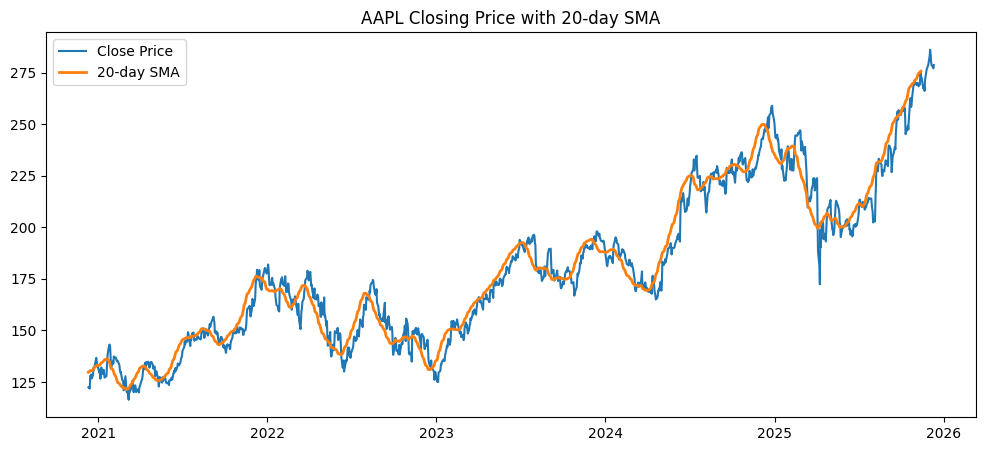

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Close"], label="Close Price")
plt.plot(df["SMA20"], label="20-day SMA", linewidth=2)
plt.title("AAPL Closing Price with 20-day SMA")
plt.legend()
plt.show()
